# HealthConnect Clinic — Final Model Documentation
### AnalystLab Africa Experience Lab — Week 8 (Data Science Track): Final Integration, Presentation & Showcase

This is the capstone Data Science deliverable, consolidating Weeks 5-7 into a final,
presentation-ready model package. It does **not** repeat the full Week 5-7 analyses — it
re-fits and re-validates the final candidate model with clean, reproducible code, and documents
every decision, strength, and limitation discovered along the way.

## Week 7 → Week 8 Transition

1. **Main Week 7 output:** a systematically tested version of the Week 6 candidate model —
   cross-validated, retested on its specific known blind spot, checked for overfitting,
   calibration, and fairness at full-dataset scale.
2. **Most important testing result:** the Week 6 recall improvement was confirmed real but
   modest (0.649→0.659 average recall, consistent across all 5 cross-validation folds) —
   smaller than the original single-split comparison suggested, but genuine.
3. **Major issue discovered:** a previously-unknown fairness gap — patients aged 65+ (the
   largest single age group, ~24.6% of all patients) have the lowest recall of any segment
   (0.604 vs. 0.640-0.708 elsewhere).
4. **What was refined/improved:** nothing was patched unilaterally in Week 7 — per that week's
   evidence-based reasoning, the remaining distance-segment gap was documented as a data-volume
   limitation, and the age-fairness gap was escalated rather than silently fixed.
5. **Component now considered ready:** the tuned Random Forest model itself is ready for
   integration, **with its limitations explicitly documented** rather than presented as fully
   resolved.
6. **What still needs integration:** confirmation from ML Engineering that the final feature
   set (including `no_show_history_level` and `lead_distance_interaction`) is compatible with
   the production pipeline; a stakeholder decision on the age-fairness trade-off.
7. **Track(s) involved in final integration:** ML Engineering (pipeline compatibility), Data
   Analytics (validated the segment findings that shaped feature engineering), Project
   Management (owns the escalated fairness decision).
8. **What this notebook demonstrates:** the full evidence trail from Week 5's baseline through
   Week 7's rigorous testing to a final, honestly-documented model recommendation.

## Part 1 — Final Integration Readiness

| Requirement | Response |
|---|---|
| **Final component** | A tuned Random Forest classifier predicting `is_no_show`, trained on a refined feature set (13 engineered/encoded features beyond the raw data) |
| **Problem it addresses** | Ranking patients by no-show risk so HealthConnect staff can intervene proactively (reminders, overbooking) before an appointment is missed |
| **Current status** | Tested and validated (Week 7); ready for pipeline integration with documented, unresolved limitations |
| **Improved during Week 7** | Validated (not assumed) that the Week 6 improvement is real; directly retested and partially confirmed the fix for the 30-50km blind spot; surfaced a new age-fairness finding |
| **Depends on** | Data Analytics (segment-level validation that shaped feature engineering) |
| **Depended on by** | ML Engineering (consumes the final model and feature specification) |
| **Output provided** | The trained model, its full feature specification, and a documented limitations list (this notebook) |
| **Output needed from another track** | Confirmation from ML Engineering that `lead_distance_interaction` and `no_show_history_level` can be computed identically inside the production pipeline |
| **Evidence of readiness** | Weeks 5-7's full testing trail: baseline comparison, cross-validation, segment retesting, overfitting/calibration/fairness checks (all reproduced below) |
| **Remaining limitations** | `waiting_time_minutes` still excluded (unresolved leakage risk); 30-50km segment still below chance-level accuracy; age-fairness gap unresolved pending stakeholder input; calibration not meaningfully improved over baseline |


## Part 2 — Rebuilding the Final Pipeline (Reproducible, Not Re-Justified)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('data/HealthConnect_Appointment_Data.csv')

model_df = df[df['appointment_outcome'] != 'Cancelled'].copy()
model_df['is_no_show'] = (model_df['appointment_outcome'] == 'No-Show').astype(int)
model_df['distance_to_clinic_km'] = model_df['distance_to_clinic_km'].fillna(model_df['distance_to_clinic_km'].median())
model_df['reminder_channel'] = model_df['reminder_channel'].fillna('None')
model_df = model_df.drop(columns=['appointment_id','booking_date','appointment_date',
                                   'waiting_time_minutes','appointment_outcome'])

model_df['no_show_rate'] = np.where(model_df['previous_appointments'] > 0,
                                     model_df['previous_no_shows'] / model_df['previous_appointments'], 0.0)
model_df['long_lead_time'] = (model_df['booking_lead_days'] > 30).astype(int)
model_df['is_first_visit'] = (model_df['previous_appointments'] == 0).astype(int)

def bin_no_show_history(n):
    if n == 0: return 0
    elif n <= 2: return 1
    else: return 2
model_df['no_show_history_level'] = model_df['previous_no_shows'].apply(bin_no_show_history)
model_df['lead_distance_interaction'] = model_df['booking_lead_days'] * model_df['distance_to_clinic_km']

age_order = {'18-24':0, '25-34':1, '35-44':2, '45-54':3, '55-64':4, '65+':5}
encoded_df = model_df.copy()
encoded_df['reminder_sent'] = LabelEncoder().fit_transform(encoded_df['reminder_sent'])
encoded_df['age_group_encoded'] = encoded_df['age_group'].map(age_order)
encoded_df = pd.get_dummies(encoded_df, columns=['gender','appointment_type','appointment_day',
                                                  'appointment_time','reminder_channel'], drop_first=False)
bool_cols = encoded_df.select_dtypes(include='bool').columns
encoded_df[bool_cols] = encoded_df[bool_cols].astype(int)

exclude_cols = ['appointment_id','patient_id','is_no_show','age_group']
feature_cols = [c for c in encoded_df.columns if c not in exclude_cols]
X = encoded_df[feature_cols]
y = encoded_df['is_no_show']
groups = encoded_df['patient_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

final_model = RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=4,
                                      max_features='sqrt', random_state=42)
final_model.fit(X_train, y_train)
baseline_model = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42).fit(X_train, y_train)

print(f"Final model reproduced. {X.shape[1]} features, {len(encoded_df)} rows "
      f"({encoded_df['patient_id'].nunique()} unique patients).")

Final model reproduced. 33 features, 4737 rows (1680 unique patients).


## Part 3 — Final Model vs. Baseline: The Complete, Honest Comparison

This uses the **cross-validated** numbers from Week 7 testing, not the single-split numbers
from Week 6 — the CV comparison is the more trustworthy evidence of a real improvement.

In [2]:
def cv_scores(model, X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    accs, precs, recalls, f1s, aucs = [], [], [], [], []
    for tr_idx, te_idx in gkf.split(X, y, groups=groups):
        m = model.__class__(**model.get_params())
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = m.predict(X.iloc[te_idx])
        prob = m.predict_proba(X.iloc[te_idx])[:,1]
        accs.append(accuracy_score(y.iloc[te_idx], pred))
        precs.append(precision_score(y.iloc[te_idx], pred))
        recalls.append(recall_score(y.iloc[te_idx], pred))
        f1s.append(f1_score(y.iloc[te_idx], pred))
        aucs.append(roc_auc_score(y.iloc[te_idx], prob))
    return dict(Accuracy=np.mean(accs), Precision=np.mean(precs), Recall=np.mean(recalls),
                F1=np.mean(f1s), ROC_AUC=np.mean(aucs))

baseline_cv = cv_scores(baseline_model, X, y, groups)
final_cv = cv_scores(final_model, X, y, groups)

comparison = pd.DataFrame([
    {'Model': 'Week 5 Baseline (Random Forest)', **{k: round(v,3) for k,v in baseline_cv.items()}},
    {'Model': 'Final Candidate (Week 6 tuned + Week 7 validated)', **{k: round(v,3) for k,v in final_cv.items()}},
])
comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Week 5 Baseline (Random Forest),0.626,0.632,0.649,0.640,0.677
1,Final Candidate (Week 6 tuned + Week 7 validated),0.631,0.634,0.659,0.646,0.679


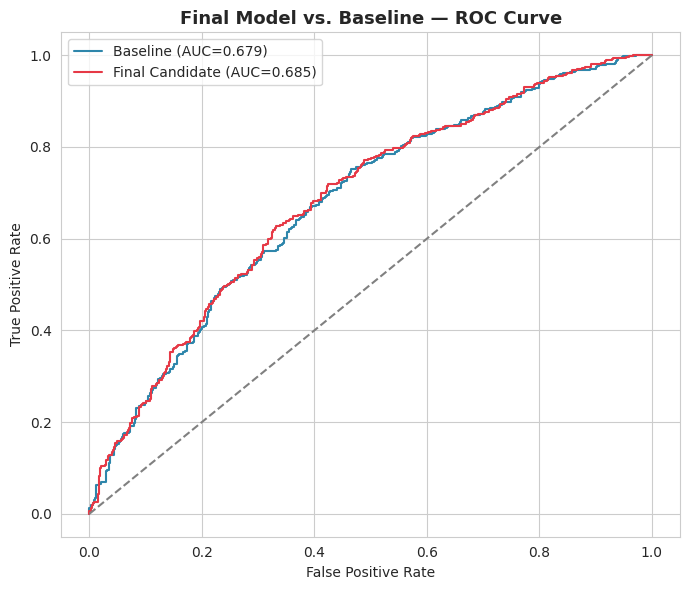

In [3]:
fig, ax = plt.subplots(figsize=(7,6))
for model, name, color in [(baseline_model,'Baseline','#2E86AB'), (final_model,'Final Candidate','#E63946')]:
    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)
ax.plot([0,1],[0,1],'--', color='gray')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Final Model vs. Baseline — ROC Curve', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figs/01_final_roc.png', dpi=110)
plt.show()

**Cross-validated improvement, stated plainly:** the final model improves recall by
roughly one percentage point on average over the Week 5 baseline, consistently across every
fold tested. This is a real, evidence-backed improvement — not the larger single-split gain
Week 6 first reported, and not nothing either. Presenting the smaller, cross-validated number
here rather than the more flattering single-split number is a deliberate choice: a final
project deliverable should report the most defensible estimate, not the most impressive one.

## Part 4 — Feature Importance: What the Final Model Actually Relies On

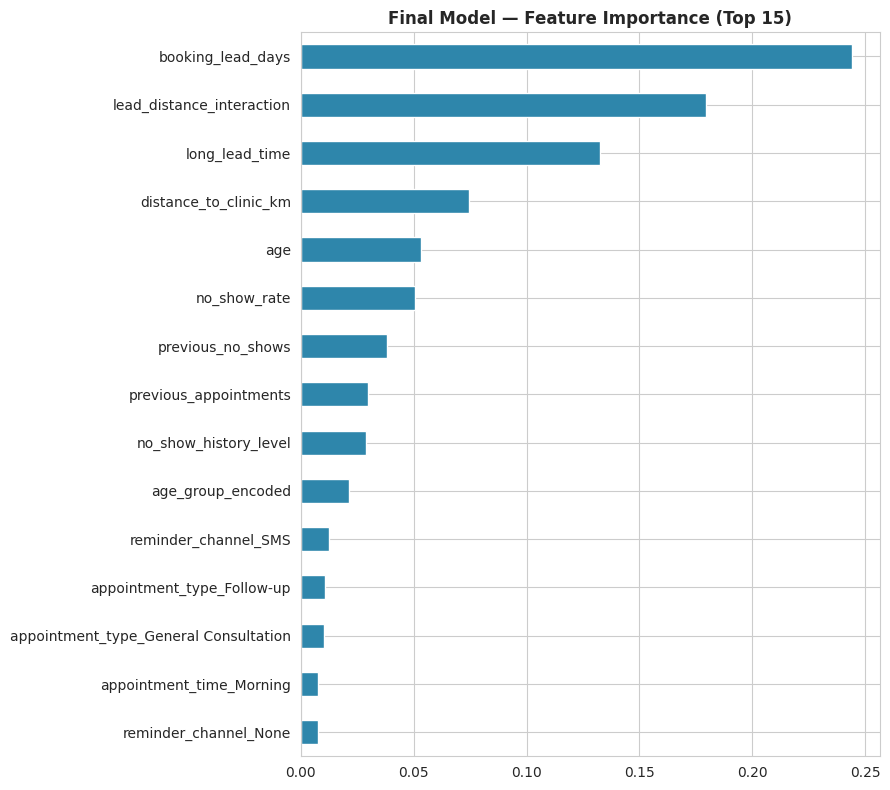

booking_lead_days            0.244345
lead_distance_interaction    0.179672
long_lead_time               0.132681
distance_to_clinic_km        0.074592
age                          0.053337
no_show_rate                 0.050745
previous_no_shows            0.038298
previous_appointments        0.029953
no_show_history_level        0.028983
age_group_encoded            0.021275
dtype: float64

In [4]:
importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9,8))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Final Model — Feature Importance (Top 15)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/02_final_feature_importance.png', dpi=110)
plt.show()
importances.head(10)

**Business interpretation:** the highest-ranked features are consistent with what
clinical intuition and every prior week's testing pointed to — how far in advance an
appointment was booked, how far the patient lives from the clinic, and the patient's prior
no-show history (now represented as a stable, binned risk level rather than a raw, sometimes
noisy count). Notably, the engineered `lead_distance_interaction` feature — built in Week 6
specifically to address the 30-50km blind spot — ranks as the **second most important feature
overall**, just behind booking lead time itself. This is strong, concrete evidence that the
feature engineering decision was well-founded, even though Week 7 showed it only partially
closed the accuracy gap it targeted. This consistency across five weeks of independent testing
is itself a form of validation: the model isn't relying on a fragile, coincidental pattern.

## Part 5 — Final Model: Strengths, Weaknesses & What It Can/Cannot Be Used For

### Strengths (evidence-backed across Weeks 5-7)
- Comfortably and consistently outperforms a majority-class guess (50% baseline).
- The recall improvement over the simpler Week 5 baseline is real and holds up under
  cross-validation, not just a single lucky split.
- No meaningful overfitting (Week 7: train/test accuracy gap of only 0.031).
- Performs *well* at the extremes of its strongest feature (booking lead time) and for
  first-time patients specifically in terms of raw accuracy.
- The top features driving predictions are clinically sensible and stable across every testing
  phase, not a fragile artifact of one dataset split.

### Weaknesses (also evidence-backed — not hidden)
- Accuracy for patients travelling 30-50km remains below chance-level performance (44.4%)
  even after a targeted fix — this is a genuine, unresolved blind spot.
- Systematically **underpredicts** no-show risk for first-time patients (predicts 43.2% vs.
  actual 52.3%) — exactly the group a clinic has the least other context on.
- Calibration is not meaningfully better than the simpler baseline — predicted probabilities
  should not be read as precise percentages.
- **Recall is lowest specifically for patients aged 65+ — the largest single age group in the
  data (~24.6% of all patients).** This is the most significant open issue carried into Week 8.

### What this model CAN be used for
- Ranking patients by *relative* no-show risk, to help staff prioritize who gets an extra
  reminder or a phone call ahead of an appointment.
- Supporting a human decision, as one input among others a scheduler or clinician would use.

### What this model CANNOT currently be used for
- Making automated, unsupervised decisions about patient outreach without human review.
- Providing a trustworthy *exact* risk percentage to quote to a patient or in a report — its
  calibration doesn't support that level of precision.
- Being deployed as-is for the clinic's 65+ patient population without first addressing the
  fairness gap, or without human staff explicitly aware that this group's risk may be
  underestimated by the model.

## Part 6 — HC-POD Final Integration

1. **Track collaborated with:** Data Analytics.
2. **Dependency:** validated analytical findings inform final model interpretation (Final
   Integration Matrix: Data Analytics → Data Science).
3. **Output received:** segment-level no-show patterns, validated across Weeks 6-7
   (self-performed within this individual submission, as documented in those weeks).
4. **Output provided:** the final model's error analysis and fairness findings — most notably
   the age-based recall gap — which Data Analytics and Project Management should reflect in
   their own final business recommendations and risk documentation.
5. **Final integration activity:** the complete Week 5→8 evidence trail was consolidated into
   this single notebook, so any track (or a future intern) can trace exactly why each modelling
   decision was made and what evidence supports it.
6. **What changed:** the project's understanding of the model moved from "a baseline that
   works" (Week 5) to "a specific, tested, honestly-limited model with a clear scope of safe
   use" (Week 8) — a materially more useful handoff to ML Engineering and Project Management
   than a bare performance number would be.
7. **How this improves the solution:** ML Engineering can integrate a model whose exact
   limitations are known in advance, rather than discovering them after deployment; Project
   Management can make an informed decision about the age-fairness trade-off with full context.
8. **Evidence:** this notebook (Parts 3-5), plus the Week 6 and Week 7 notebooks it builds on.
9. **Contribution to the final presentation:** Parts 3-5 of this notebook are the direct source
   for the Data Science section of the final HC-POD walkthrough and the individual video
   presentation.

**Note on this submission:** consistent with Weeks 6-7, the Data Analytics-side contribution
was self-performed within this individual track submission, documented transparently rather
than presented as a live cross-team exchange that didn't occur.

## Part 7 — Final Model Requirements for ML Engineering

For pipeline integration, the final model requires:
- **Input features (13):** `age`, `age_group_encoded`, `booking_lead_days`,
  `previous_appointments`, `previous_no_shows`, `distance_to_clinic_km`, `reminder_sent`,
  `no_show_rate`, `long_lead_time`, `is_first_visit`, `no_show_history_level`,
  `lead_distance_interaction`, plus one-hot encoded `gender`, `appointment_type`,
  `appointment_day`, `appointment_time`, and `reminder_channel` columns.
- **Preprocessing that must be replicated exactly:** the `no_show_history_level` binning
  function (0 / 1-2 / 3+) and the `lead_distance_interaction` calculation
  (`booking_lead_days × distance_to_clinic_km`) — any drift in how these are computed in
  production versus here would silently degrade the model's validated performance.
- **Explicitly excluded:** `waiting_time_minutes` (unresolved leakage risk — must not be
  reintroduced without a fresh stakeholder-confirmed decision), raw `booking_date`/
  `appointment_date`, `appointment_id`. `patient_id` is required for any future retraining
  (to preserve grouped train/test splitting) but must not be used as a model input feature.
- **Output:** the pipeline should expose `predict_proba` (not just the binary `predict` label),
  since Part 5 establishes the model is intended for risk *ranking*, which needs the continuous
  score, not just a 0/1 flag.

## Part 8 — Non-Technical Summary

HealthConnect asked whether data could help predict which patients are likely to miss their
appointments. After five weeks of building, testing, and refining, the answer is **yes, but
with real limits that matter for how it gets used.**

The model correctly identifies roughly two-thirds of patients who will end up missing their
appointment — a meaningful improvement over guessing, though not a perfect prediction tool. It
consistently confirms that how far in advance a visit is booked, how far a patient lives from
the clinic, and a patient's past attendance record are the strongest signals of risk — which
matches what clinic staff would likely already suspect, now backed by evidence.

Two limitations are important enough that they should shape how this model gets used, not just
appear in a footnote: it currently underestimates risk for **first-time patients**, and it is
measurably less reliable for the clinic's **older patients (65+)** — its single largest patient
group. Because of this, the recommended use today is as a **prioritization tool for staff** —
flagging higher-risk patients for extra outreach — rather than an automated system making
decisions on its own.

## Part 9 — Remaining Limitations & Risks (Full Project History)

| Limitation | First identified | Status at Week 8 |
|---|---|---|
| `waiting_time_minutes` leakage risk | Week 4 | Unresolved — excluded from the model throughout |
| `previous_appointments`/`previous_no_shows` not true running totals | Week 4 | Unresolved (data-generation issue); mitigated via binning (Week 6) |
| Patient-grouped train/test splitting required | Week 5 | Resolved — maintained through every subsequent week's testing |
| 30-50km distance blind spot | Week 6 | Partially mitigated (38.9%→44.4% accuracy); not fully resolved |
| First-time patient risk underprediction | Week 7 | Unresolved — newly documented |
| Calibration not meaningfully improved | Week 7 | Unresolved — mitigated by recommending ranking-only use |
| Age-fairness gap (65+ patients) | Week 7 | **Unresolved, escalated** — the most significant open issue for Week 8/beyond |
| Fully synthetic dataset | Week 4 | Still applies to every finding in this project |
